In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


NameError: name 'r2_moist_E' is not defined

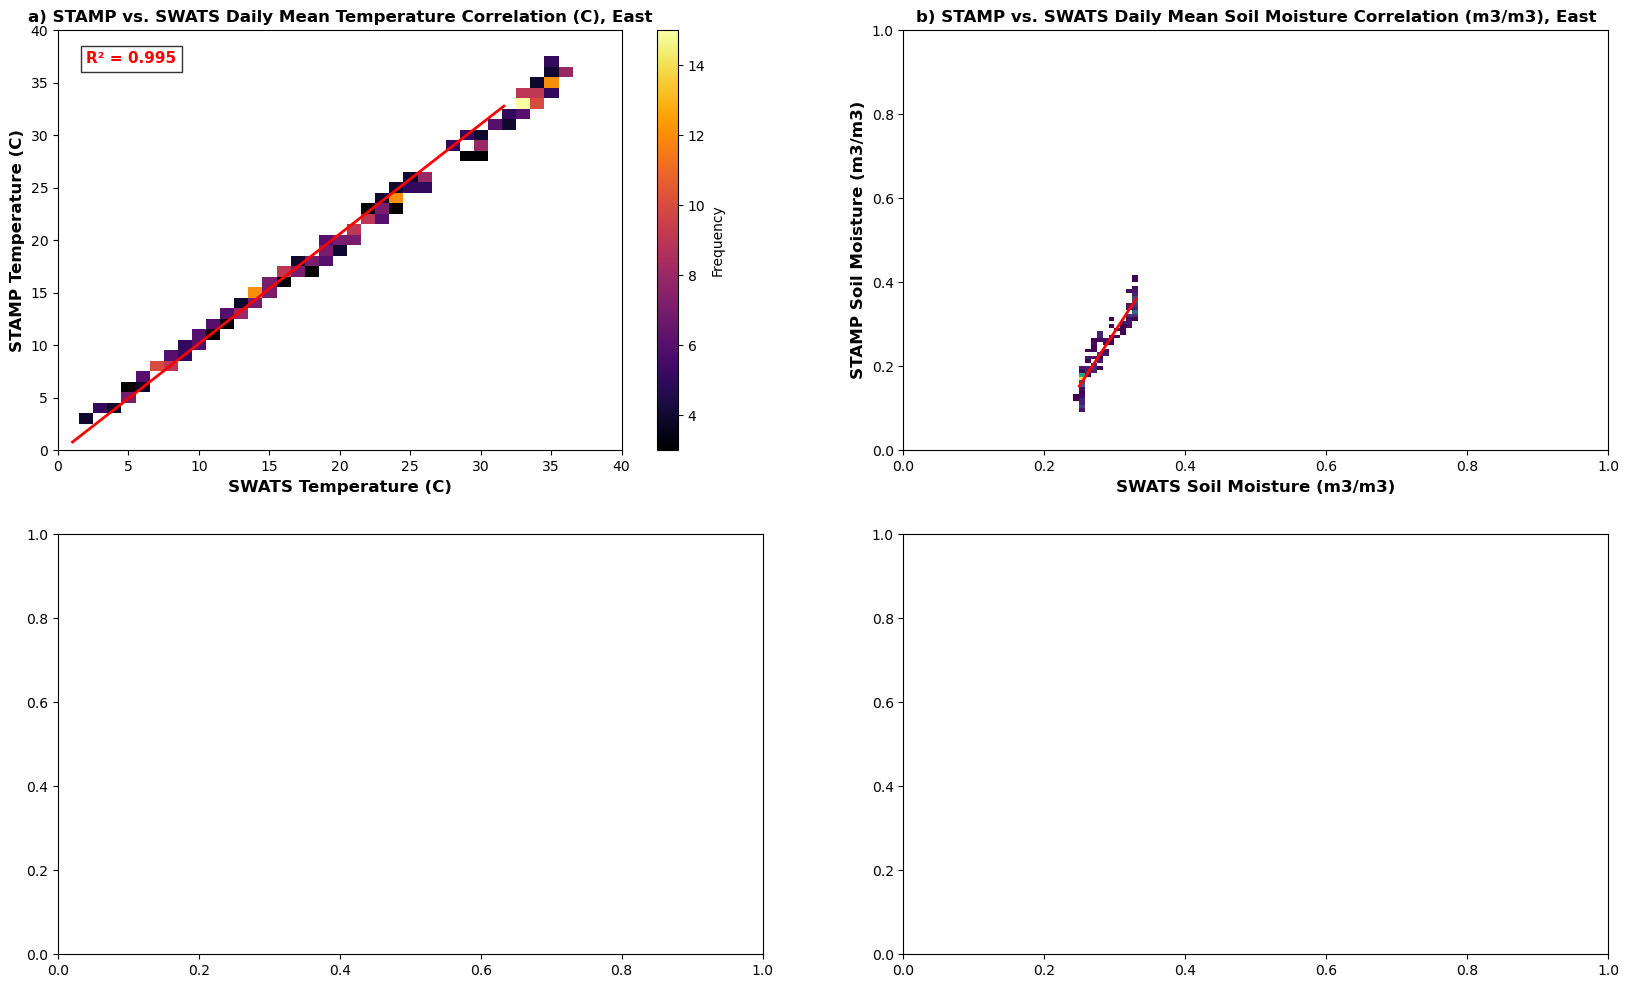

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import seaborn as sns

files_swats = sorted(glob.glob('/Users/dave121504/ARM Project/SWATS Files/sgpswats*.nc'))
swats = xr.open_mfdataset(files_swats, combine='by_coords')

files_stamp = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Files/sgpstamp*.nc'))
stamp = xr.open_mfdataset(files_stamp, combine='by_coords')


## EAST ##

#TEMPERATURE
swats_tempE_5 = swats['tsoil_e'].isel(depth=0)
swats_daily_temp_E_5 = swats_tempE_5.resample(time='1D').mean()


stamp_tempE_5 = stamp['soil_temperature_east'].isel(depth=0)
stamp_daily_tempE_5 = stamp_tempE_5.resample(time='1D').mean()


swats_temp_aligned, stamp_temp_aligned = xr.align(swats_daily_temp_E_5, stamp_daily_tempE_5, join='inner')
swats_temp_aligned = swats_temp_aligned.compute()
stamp_temp_aligned = stamp_temp_aligned.compute()

valid = np.isfinite(swats_temp_aligned) & np.isfinite(stamp_temp_aligned)
x = swats_temp_aligned.where(valid, drop=True).values
y = stamp_temp_aligned.where(valid, drop=True).values

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

heatmap1, xedges1, yedges1 = np.histogram2d(x, y, bins = 40)
heatmap1_masked = np.ma.masked_where(heatmap1 <= 2, heatmap1)
cmap = plt.cm.inferno.copy()
cmap.set_bad(color='white')   # empty bins appear white

im1 = axes[0,0].imshow(heatmap1_masked.T, origin = 'lower', cmap = cmap, aspect = 'auto')
axes[0,0].plot(x_line, y_line, color = 'red', linewidth = 2)
axes[0,0].set_ylabel('STAMP Temperature (C)', fontsize = 12, fontweight = 'bold')
axes[0,0].set_xlabel('SWATS Temperature (C)',fontsize = 12, fontweight = 'bold')
axes[0,0].set_title('a) STAMP vs. SWATS Daily Mean Temperature Correlation (C), East', fontsize = 12, fontweight = 'bold')
r2_temp_E = np.corrcoef(x, y)[0, 1] ** 2
axes[0,0].text(0.05, 0.95,f"R² = {r2_temp_E:.3f}",transform=axes[0,0].transAxes, fontsize=11, color = 'red', fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
fig.colorbar(im1, ax = axes[0,0], label = 'Frequency')
axes[0,0].set_xlim(0, 40)
axes[0,0].set_ylim(0, 40)

#MOISTURE, WEST
swats_spec_moist_E = swats['watcont_e'].isel(depth=0)
stamp_spec_moist_E = stamp['soil_specific_water_content_east'].isel(depth=0)
stamp_moist_E = stamp_spec_moist_E / 100
swats_daily_moist_E = swats_spec_moist_E.resample(time = '1D').mean()
stamp_daily_moist_E = stamp_moist_E.resample(time = '1D').mean()

swats_moist_aligned, stamp_moist_aligned = xr.align(swats_daily_moist_E, stamp_daily_moist_E, join='inner')
swats_moist_aligned = swats_moist_aligned.compute()
stamp_moist_aligned = stamp_moist_aligned.compute()

valid1 = np.isfinite(swats_moist_aligned) & np.isfinite(stamp_moist_aligned)
x2 = swats_moist_aligned.where(valid1, drop = True).values
y2 = stamp_moist_aligned.where(valid1, drop = True).values

m2, b2 = np.polyfit(x2, y2, 1)
x2_line = np.linspace(x2.min(), x2.max(), 100)
y2_line = m2 * x2_line + b2

heatmap2, xedges2, yedges2 = np.histogram2d(x2, y2, bins = 120, range = [[0,1], [0,1]])
heatmap2_masked = np.ma.masked_where(heatmap2 <= 2, heatmap2)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')   # empty bins appear white

im2 = axes[0,1].imshow(heatmap2_masked.T, origin = 'lower', cmap = cmap, aspect = 'auto', extent = [xedges2[0], xedges2[-1], yedges2[0], yedges2[-1]])
axes[0,1].plot(x2_line, y2_line, color = 'red', linewidth = 2)
axes[0,1].set_ylabel('STAMP Soil Moisture (m3/m3)', fontsize = 12, fontweight = 'bold')
axes[0,1].set_xlabel('SWATS Soil Moisture (m3/m3)',fontsize = 12, fontweight = 'bold')
axes[0,1].set_title('b) STAMP vs. SWATS Daily Mean Soil Moisture Correlation (m3/m3), East', fontsize = 12, fontweight = 'bold')
r2_temp_E = np.corrcoef(x2, y2)[0, 1] ** 2
axes[0,1].text(0.05, 0.95,f"R² = {r2_moist_E:.3f}",transform=axes[0,1].transAxes, fontsize=11, color = 'red', fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
fig.colorbar(im2, ax = axes[0,1], label = 'Frequency')

axes[0,1].set_xlim(0.225, 0.35)
axes[0,1].set_ylim(0.15, 0.375)


#WEST#
swats_tempW_5 = swats['tsoil_w'].isel(depth=0)
swats_daily_temp_W_5 = swats_tempW_5.resample(time='1D').mean()


stamp_tempW_5 = stamp['soil_temperature_west'].isel(depth=0)
stamp_daily_tempW_5 = stamp_tempW_5.resample(time='1D').mean()


swats_temp_alignedW, stamp_temp_alignedW = xr.align(swats_daily_temp_W_5, stamp_daily_tempW_5, join='inner')
swats_temp_alignedW = swats_temp_alignedW.compute()
stamp_temp_alignedW = stamp_temp_alignedW.compute()

validW = np.isfinite(swats_temp_alignedW) & np.isfinite(stamp_temp_alignedW)
x3 = swats_temp_alignedW.where(validW, drop=True).values
y3 = stamp_temp_alignedW.where(validW, drop=True).values

m3, b3 = np.polyfit(x3, y3, 1)
x3_line = np.linspace(x3.min(), x3.max(), 100)
y3_line = m3 * x3_line + b3

heatmap3, xedges3, yedges3 = np.histogram2d(x3, y3, bins = 40)
heatmap3_masked = np.ma.masked_where(heatmap3 <= 2, heatmap3)
im3 = axes[1,0].imshow(heatmap3_masked.T, origin = 'lower', cmap = cmap, aspect = 'auto')
axes[1,0].plot(x3_line, y3_line, color = 'red', linewidth = 2)
axes[1,0].set_ylabel('STAMP Temperature (C)', fontsize = 12, fontweight = 'bold')
axes[1,0].set_xlabel('SWATS Temperature (C)',fontsize = 12, fontweight = 'bold')
axes[1,0].set_title('c) STAMP vs. SWATS Daily Mean Temperature Correlation (C), West', fontsize = 12, fontweight = 'bold')
r2_temp_W = np.corrcoef(x3, y3)[0, 1] ** 2
axes[1,0].text(0.05, 0.95,f"R² = {r2_temp_W:.3f}",transform=axes[1,0].transAxes, fontsize=11, color = 'red', fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
fig.colorbar(im3, ax = axes[1,0], label = 'Frequency')
axes[1,0].set_xlim(0, 40)
axes[1,0].set_ylim(0, 40)

#MOISTURE, WEST
swats_spec_moist_W = swats['watcont_w'].isel(depth=0)
stamp_spec_moist_W = stamp['soil_specific_water_content_west'].isel(depth=0)
stamp_moist_W = stamp_spec_moist_W / 100
swats_daily_moist_W = swats_spec_moist_W.resample(time = '1D').mean()
stamp_daily_moist_W = stamp_moist_W.resample(time = '1D').mean()

swats_moist_alignedW, stamp_moist_alignedW = xr.align(swats_daily_moist_W, stamp_daily_moist_W, join='inner')
swats_moist_alignedW = swats_moist_alignedW.compute()
stamp_moist_alignedW = stamp_moist_alignedW.compute()

validW2 = np.isfinite(swats_moist_alignedW) & np.isfinite(stamp_moist_alignedW)
x4 = swats_moist_alignedW.where(validW2, drop = True).values
y4 = stamp_moist_alignedW.where(validW2, drop = True).values

m4, b4 = np.polyfit(x4, y4, 1)
x4_line = np.linspace(x4.min(), x4.max(), 100)
y4_line = m4 * x4_line + b4

heatmap4, xedges4, yedges4 = np.histogram2d(x4, y4, bins = 120, range = [[0,1], [0,1]])
heatmap4_masked = np.ma.masked_where(heatmap4 <= 2, heatmap4)

im4 = axes[1,1].imshow(heatmap4_masked.T, origin = 'lower', cmap = cmap, aspect = 'auto', extent = [xedges4[0], xedges4[-1], yedges4[0], yedges4[-1]])
axes[1,1].plot(x4_line, y4_line, color = 'red', linewidth = 2)
axes[1,1].set_ylabel('STAMP Soil Moisture (m3/m3)', fontsize = 12, fontweight = 'bold')
axes[1,1].set_xlabel('SWATS Soil Moisture (m3/m3)',fontsize = 12, fontweight = 'bold')
axes[1,1].set_title('d) STAMP vs. SWATS Daily Mean Soil Moisture Correlation (m3/m3), West', fontsize = 12, fontweight = 'bold')
r2_moist_W = np.corrcoef(x4, y4)[0, 1] ** 2
axes[1,1].text(0.05, 0.95,f"R² = {r2_moist_W:.3f}",transform=axes[1,1].transAxes, fontsize=11, color = 'red', fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
fig.colorbar(im4, ax = axes[1,1], label = 'Frequency')
axes[1,1].set_xlim(0.2, 0.4)
axes[1,1].set_ylim(0, 0.3)


axes[0,0].grid(alpha = 0.5)
axes[0,1].grid(alpha = 0.5)
axes[1,0].grid(alpha = 0.5)
axes[1,1].grid(alpha = 0.5)

plt.suptitle(f'Temperature (C) and Soil Moisture (m3/m3) Heat Maps, 5 cm Depth, \n 2016/02/22 to 2017/07/03', fontweight = 'bold', fontsize = 16)
plt.subplots_adjust(hspace=0.4, wspace = 0.2)